In [ ]:
import shutil
from pathlib import Path
import yaml
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
from ultralytics import YOLO

In [2]:
IMAGES_PATH = Path("/kaggle/input/kitti-dataset/data_object_image_2/training/image_2")
LABELS_PATH = Path("/kaggle/input/kitti-dataset-yolo-format/labels")
OUTPUT_PATH = Path("/kaggle/working")

In [3]:
def copy_files(files, labels_path, output_path):
    for image_path in files:
        # Save the label in the same directory as the image
        label_path = labels_path / f"{image_path.stem}.txt"
        if not label_path.exists():
            print(f"Missing label for {image_path.name}")
            continue
        shutil.copy(image_path, output_path / "images" / image_path.name)
        shutil.copy(label_path, output_path / "labels" / label_path.name)
    print(f"Files saved succesfully in {output_path}")

def train_test_split(images_path, labels_path, output_path, train_ratio=0.8):
    train_path = output_path / "train"
    test_path  = output_path / "test"

    # Create the directories for the training and testing data
    (train_path / "images").mkdir(parents=True, exist_ok=True)
    (train_path / "labels").mkdir(parents=True, exist_ok=True)

    (test_path / "images").mkdir(parents=True, exist_ok=True)
    (test_path / "labels").mkdir(parents=True, exist_ok=True)

    # List all the images and shuffle them before splitting
    all_images = list(images_path.glob("*.png"))
    random.shuffle(all_images)

    num_train_samples = int(train_ratio * len(all_images))
    train_files = all_images[:num_train_samples]
    test_files  = all_images[num_train_samples:]
    print(f"Dataset split into {len(train_files)} training and {len(test_files)} testing samples")

    # Save the data in the output path
    copy_files(train_files, labels_path, train_path)
    copy_files(test_files, labels_path, test_path)

In [4]:
train_test_split(IMAGES_PATH, LABELS_PATH, OUTPUT_PATH)

Dataset split into 5984 training and 1497 testing samples
Files saved succesfully in /kaggle/working/train
Files saved succesfully in /kaggle/working/test


In [ ]:
# !pip install -U ultralytics
# !pip install "numpy<2" --force-reinstall
# !pip install --upgrade --force-reinstall scipy==1.11.4

In [5]:
class_dictionary = {
    'Car': 0,
    'Pedestrian': 1,
    'Van': 2,
    'Cyclist': 3,
    'Truck': 4,
    'Misc': 5,
    'Tram': 6,
    'Person_sitting': 7
}
class_names = list(class_dictionary.keys())

yaml_content = {
    "train": str(OUTPUT_PATH / "train" / "images"),
    "val": str(OUTPUT_PATH / "test" / "images"),
    "nc": len(class_names),
    "names": class_names
}

with open(OUTPUT_PATH / "data.yaml", "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

In [ ]:
model = YOLO("yolov8s.pt")

In [8]:
train_results = model.train(
    data= OUTPUT_PATH / 'data.yaml', 
    epochs=50,
    patience=5,
    mixup=0.1,
    project='yolo-kitti',
    device=[0,1]
)

Ultralytics 8.3.229 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, opti

In [22]:
model = YOLO(OUTPUT_PATH / 'yolo-kitti/train2/weights/best.pt')
validation_results = model.val()


Ultralytics 8.3.229 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3371.2±983.8 MB/s, size: 780.6 KB)
val: Scanning /kaggle/working/test/labels.cache... 1497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1497/1497 2.5Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 7.3it/s 12.9s0.1s
                   all       1497       7961      0.909      0.869      0.923       0.69
                   Car       1337       5590      0.937      0.926      0.974      0.825
            Pedestrian        356        929      0.883      0.738      0.851      0.516
                   Van        401        546      0.932      0.914      0.958      0.791
               Cyclist        240        344      0.908      0.804      0.892      0.629
                 Truck        204      

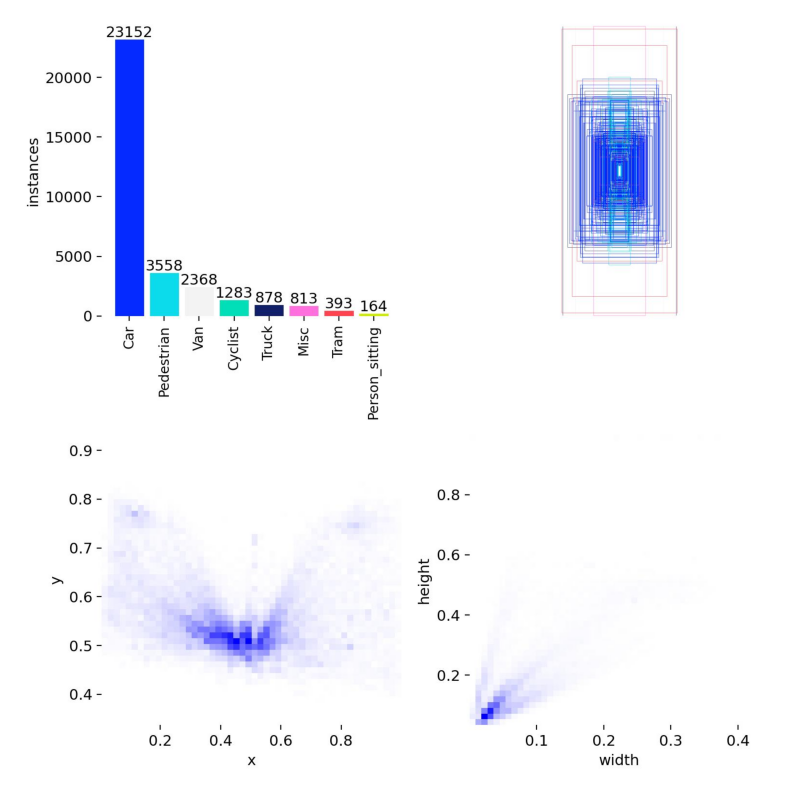

In [23]:
plt.figure(figsize=(10,20))
plt.imshow(Image.open(OUTPUT_PATH / 'yolo-kitti/train2/labels.jpg'))
plt.axis('off')
plt.show()

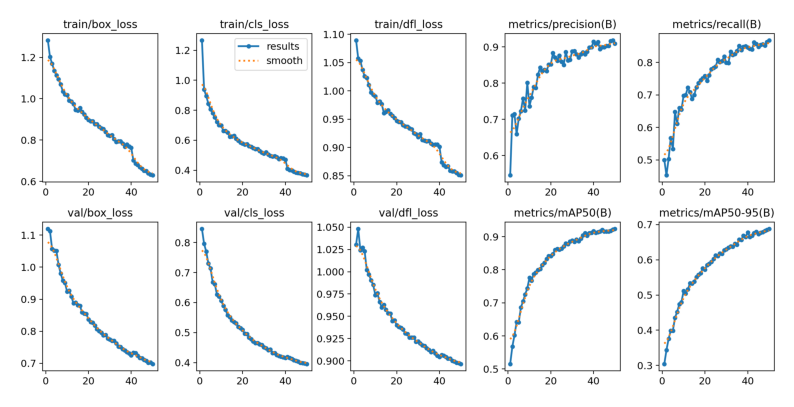

In [24]:
plt.figure(figsize=(10,20))
plt.imshow(Image.open(OUTPUT_PATH / 'yolo-kitti/train2/results.png'))
plt.axis('off')
plt.show()

[[     819.01      188.28      1241.1      373.51]
 [     244.33      246.53      434.03      355.44]
 [        700      193.18      917.14      335.63]
 [     521.65      183.29      560.01      216.64]
 [     370.19      196.25      506.72      291.78]
 [      634.3      180.37      670.15       209.4]] [    0.94289     0.94142     0.93224     0.91018     0.89886     0.87659] [          0           5           0           0           0           0]


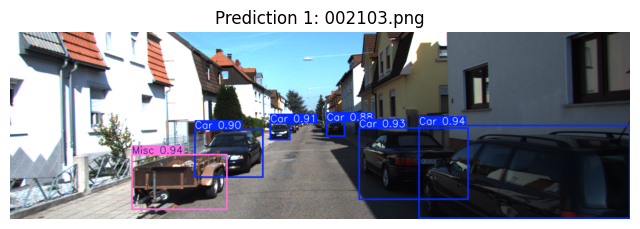

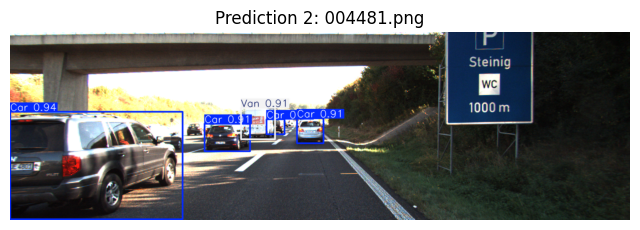

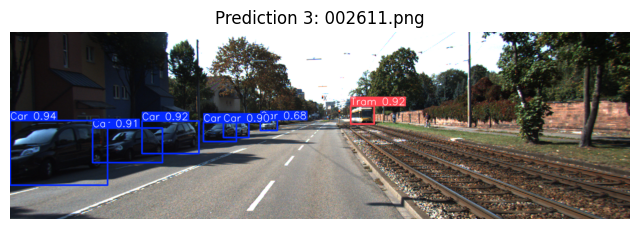

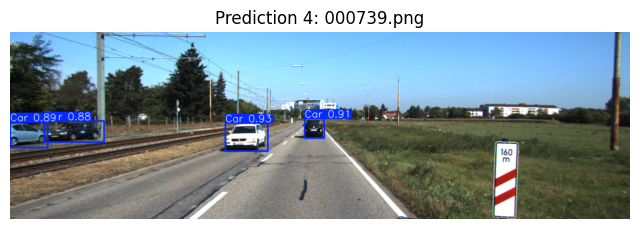

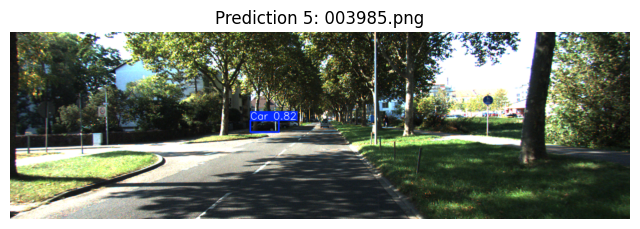

In [31]:
def predict(images, confidence_threshold=0.6):
    results = model.predict(
        source=images, conf=confidence_threshold, imgsz=640, device=0, verbose=False)
    return results

def process_results(results):
    for result in results:
        boxes = result.boxes  # Boxes object
    
        xyxy = boxes.xyxy.cpu().numpy()   # (N, 4)
        conf = boxes.conf.cpu().numpy()   # (N,)
        cls  = boxes.cls.cpu().numpy()    # (N,)
        print(xyxy, conf, cls)
        return

    

# Read the test files
test_path = OUTPUT_PATH / "test/images"
image_files = [
    os.path.join(test_path, file) for file in os.listdir(test_path) if file.lower().endswith(('.jpg', '.png', '.jpeg'))]

random_images = random.sample(image_files, 5)

results = predict(random_images)
process_results(results)

for i, result in enumerate(results):
    plotted_img = result.plot()
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Prediction {i+1}: {os.path.basename(random_images[i])}")
    plt.show()

In [27]:
!zip -r working_files.zip /kaggle/working/yolo-kitti/train2

  adding: kaggle/working/yolo-kitti/train2/ (stored 0%)
  adding: kaggle/working/yolo-kitti/train2/labels.jpg (deflated 32%)
  adding: kaggle/working/yolo-kitti/train2/train_batch1.jpg (deflated 14%)
  adding: kaggle/working/yolo-kitti/train2/confusion_matrix.png (deflated 22%)
  adding: kaggle/working/yolo-kitti/train2/train_batch0.jpg (deflated 13%)
  adding: kaggle/working/yolo-kitti/train2/val_batch1_labels.jpg (deflated 10%)
  adding: kaggle/working/yolo-kitti/train2/val_batch1_pred.jpg (deflated 9%)
  adding: kaggle/working/yolo-kitti/train2/train_batch14961.jpg (deflated 24%)
  adding: kaggle/working/yolo-kitti/train2/BoxR_curve.png (deflated 7%)
  adding: kaggle/working/yolo-kitti/train2/val_batch2_pred.jpg (deflated 10%)
  adding: kaggle/working/yolo-kitti/train2/train_batch2.jpg (deflated 14%)
  adding: kaggle/working/yolo-kitti/train2/val_batch0_labels.jpg (deflated 11%)
  adding: kaggle/working/yolo-kitti/train2/BoxPR_curve.png (deflated 10%)
  adding: kaggle/working/yolo-k

In [29]:
import os
from IPython.display import FileLink

FileLink(r"working_files.zip")

/kaggle/working/working_files.zip